# Phase 7 — Streamlit Inference Preparation

This notebook prepares the project artifacts and validates the app inference layer before launching the Streamlit UI.

## Objectives
- load all required project configs
- verify classification and detection app settings
- verify trained artifact availability
- validate classifier registry construction
- validate class mapping loading
- run a dry classification inference on one sample image
- optionally run a dry YOLOv8 detection inference on one sample image
- confirm screenshot/output directories for the app phase
- prepare the project for `streamlit run app/app.py`

## Expected outputs
- confirmed paths and configs
- validated classifier registry
- successful sample prediction payload
- successful optional detection payload
- ready-to-run app structure

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.1 MB/s eta 0:00:00


In [7]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import load_project_configs
from src.utils.paths import load_paths_config
from src.utils.io import load_json
from src.app.inference_classifier import (
    resolve_enabled_classifier_registry,
    load_class_mapping,
    load_keras_model,
    predict_with_loaded_classifier,
)
from src.app.inference_detector import load_detector, run_detector_on_image
from src.app.image_utils import save_pil_image
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Load project configuration files

This cell loads the YAML configuration files that drive dataset paths, model artifacts, detection settings, and Streamlit UI behavior.

In [8]:
CONFIGS_DIR = PROJECT_ROOT / "configs"
CONFIGS = load_project_configs(CONFIGS_DIR)

PATHS_CFG = CONFIGS["paths"]
CLASSIFICATION_CFG = CONFIGS["classification"]
TRANSFER_CFG = CONFIGS["transfer_learning"]
DETECTION_CFG = CONFIGS["detection"]
STREAMLIT_CFG = CONFIGS["streamlit"]

PATH_OBJECTS = load_paths_config(CONFIGS_DIR / "paths.yaml")

print("Loaded configs:", list(CONFIGS.keys()))
print("Project root:", PROJECT_ROOT)

Loaded configs: ['paths', 'classification', 'transfer_learning', 'detection', 'streamlit']
Project root: /content/drive/MyDrive/Aerial_Object_Classification_Detection


## Inspect the Streamlit configuration

This cell prints the most important sections used by the app:
- app metadata
- classifier registry
- detector settings
- artifact save locations

In [9]:
print(json.dumps(STREAMLIT_CFG["app"], indent=2))
print()
print("Classifier keys:", list(STREAMLIT_CFG.get("classification", {}).get("models", {}).keys()))
print("Detection enabled:", STREAMLIT_CFG.get("detection", {}).get("enabled", False))
print("Artifacts:", json.dumps(STREAMLIT_CFG.get("artifacts", {}), indent=2))

{
  "title": "Aerial Object Classification & Detection",
  "layout": "wide",
  "sidebar_state": "expanded",
  "page_icon": "\ud83d\udef0\ufe0f"
}

Classifier keys: ['custom_cnn', 'mobilenet', 'resnet50', 'efficientnetb0']
Detection enabled: True
Artifacts: {
  "temp_upload_dir": "data/interim/app_uploads",
  "app_figure_dir": "figures/app",
  "docs_image_dir": "docs/images",
  "home_placeholder_path": "figures/app/streamlit_home.png",
  "classifier_example_path": "figures/app/streamlit_classifier_output.png",
  "detector_example_path": "figures/app/streamlit_detector_output.png",
  "docs_home_path": "docs/images/streamlit_home.png",
  "docs_prediction_path": "docs/images/streamlit_prediction.png",
  "docs_detection_path": "docs/images/streamlit_detection.png"
}


## Resolve app-phase directories

This cell resolves upload, figures, and documentation image directories used by the Streamlit app.

In [10]:
ARTIFACT_CFG = STREAMLIT_CFG.get("artifacts", {})

temp_upload_dir = PROJECT_ROOT / ARTIFACT_CFG.get("temp_upload_dir", "data/interim/app_uploads")
app_figure_dir = PROJECT_ROOT / ARTIFACT_CFG.get("app_figure_dir", "figures/app")
docs_image_dir = PROJECT_ROOT / ARTIFACT_CFG.get("docs_image_dir", "docs/images")

temp_upload_dir.mkdir(parents=True, exist_ok=True)
app_figure_dir.mkdir(parents=True, exist_ok=True)
docs_image_dir.mkdir(parents=True, exist_ok=True)

print("temp_upload_dir:", temp_upload_dir)
print("app_figure_dir:", app_figure_dir)
print("docs_image_dir:", docs_image_dir)

temp_upload_dir: /content/drive/MyDrive/Aerial_Object_Classification_Detection/data/interim/app_uploads
app_figure_dir: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/app
docs_image_dir: /content/drive/MyDrive/Aerial_Object_Classification_Detection/docs/images


## Validate classifier registry

This cell builds the config-driven classifier registry and verifies that the configured model and class-mapping artifacts exist.

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features.class_mapping import build_class_mappings, save_class_mapping_artifact

train_dir = PROJECT_ROOT / "data" / "processed" / "classification" / "train"
class_names = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])

class_to_index, index_to_class = build_class_mappings(class_names)

output_path = PROJECT_ROOT / "models" / "classification" / "custom_cnn" / "class_mapping.json"
save_class_mapping_artifact(
    class_to_index=class_to_index,
    index_to_class=index_to_class,
    output_path=output_path,
)

print("Saved:", output_path)
print("class_to_index:", class_to_index)
print("index_to_class:", index_to_class)

Saved: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/class_mapping.json
class_to_index: {'bird': 0, 'drone': 1}
index_to_class: {0: 'bird', 1: 'drone'}


In [13]:
classifier_registry = resolve_enabled_classifier_registry(
    project_root=PROJECT_ROOT,
    streamlit_config=STREAMLIT_CFG,
)

print("Resolved classifier registry keys:", list(classifier_registry.keys()))

for model_key, entry in classifier_registry.items():
    print("\nMODEL:", model_key)
    print(" display_name:", entry["display_name"])
    print(" model_path exists:", Path(entry["model_path"]).exists(), Path(entry["model_path"]))
    print(" class_mapping_path exists:", Path(entry["class_mapping_path"]).exists(), Path(entry["class_mapping_path"]))
    print(" preprocess_mode:", entry["preprocess_mode"])
    print(" backbone_name:", entry.get("backbone_name"))

Resolved classifier registry keys: ['custom_cnn', 'mobilenet', 'resnet50', 'efficientnetb0']

MODEL: custom_cnn
 display_name: Custom CNN
 model_path exists: True /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/final_model.keras
 class_mapping_path exists: True /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/class_mapping.json
 preprocess_mode: custom
 backbone_name: None

MODEL: mobilenet
 display_name: MobileNetV2 Transfer
 model_path exists: True /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/final_model.keras
 class_mapping_path exists: True /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/final/class_mapping.json
 preprocess_mode: transfer
 backbone_name: mobilenetv2

MODEL: resnet50
 display_name: ResNet50 Transfer
 model_path exists: True /content/drive/MyDrive/Aerial_Object_Classification_Detection/models

## Preview a class mapping

This cell loads the class mapping for the default classifier and confirms that class order is consistent for inference.

In [14]:
default_model_key = STREAMLIT_CFG.get("classification", {}).get("default_model_key", list(classifier_registry.keys())[0])
default_entry = classifier_registry[default_model_key]

class_mapping = load_class_mapping(default_entry["class_mapping_path"])
print(class_mapping)

{'class_to_index': {'bird': 0, 'drone': 1}, 'index_to_class': {0: 'bird', 1: 'drone'}, 'class_names': ['bird', 'drone']}


## Select one sample image for inference smoke testing

This cell uses the processed classification dataset and picks a sample image from the test split.

In [15]:
processed_classification_dir = PROJECT_ROOT / "data" / "processed" / "classification"
test_image_candidates = sorted((processed_classification_dir / "test").rglob("*.jpg"))

if len(test_image_candidates) == 0:
    raise FileNotFoundError("No test images found under data/processed/classification/test")

sample_classification_image = test_image_candidates[0]
sample_classification_image

PosixPath('/content/drive/MyDrive/Aerial_Object_Classification_Detection/data/processed/classification/test/bird/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg')

## Display the sample classification image

This cell opens the image that will be used for the dry-run classifier inference.

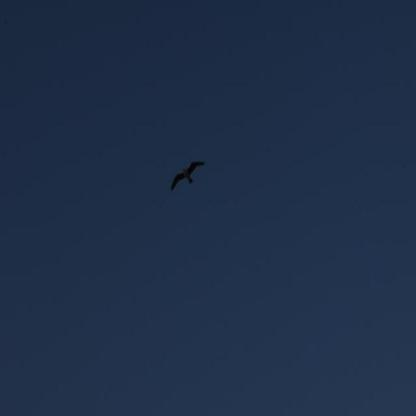

In [16]:
sample_pil_image = Image.open(sample_classification_image).convert("RGB")
sample_pil_image

## Load the selected classifier model

This cell loads the saved Keras classifier artifact without recompiling it.

In [17]:
classifier_model = load_keras_model(default_entry["model_path"])
type(classifier_model)

keras.src.models.functional.Functional

## Run dry classification inference

This cell runs one sample prediction using the same inference logic that the Streamlit classification page will use.

In [18]:
classification_prediction = predict_with_loaded_classifier(
    model=classifier_model,
    image=sample_pil_image,
    class_mapping=class_mapping,
    preprocess_mode=default_entry["preprocess_mode"],
    backbone_name=default_entry.get("backbone_name"),
    image_size=tuple(CLASSIFICATION_CFG["custom_cnn"]["training"]["image_size"]),
)

classification_prediction

{'predicted_index': 1,
 'predicted_label': 'drone',
 'confidence': 0.574670672416687,
 'probabilities': {'drone': 0.574670672416687, 'bird': 0.425329327583313},
 'preprocess_mode': 'transfer',
 'backbone_name': 'mobilenetv2',
 'image_size': (224, 224),
 'class_names': ['bird', 'drone']}

## Save a classification preview artifact

This cell saves the sample image to the configured app/docs locations so the app phase has reusable assets.

In [19]:
classifier_example_path = PROJECT_ROOT / ARTIFACT_CFG.get(
    "classifier_example_path",
    "figures/app/streamlit_classifier_output.png",
)
docs_prediction_path = PROJECT_ROOT / ARTIFACT_CFG.get(
    "docs_prediction_path",
    "docs/images/streamlit_prediction.png",
)

save_pil_image(sample_pil_image, classifier_example_path)
save_pil_image(sample_pil_image, docs_prediction_path)

print(classifier_example_path)
print(docs_prediction_path)

/content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/app/streamlit_classifier_output.png
/content/drive/MyDrive/Aerial_Object_Classification_Detection/docs/images/streamlit_prediction.png


## Optional detector artifact check

This cell checks whether the final YOLOv8 detector artifact is available for app inference.

In [20]:
detector_model_path = PROJECT_ROOT / STREAMLIT_CFG.get("detection", {}).get(
    "detector_model_path",
    "models/detection/final/best_detector.pt",
)

print("Detector enabled:", STREAMLIT_CFG.get("detection", {}).get("enabled", False))
print("Detector path:", detector_model_path)
print("Detector exists:", detector_model_path.exists())

Detector enabled: True
Detector path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/detection/final/best_detector.pt
Detector exists: True


## Select a sample detection image

If the detector artifact exists, this cell selects one image from the processed detection test split for a dry-run detection check.

In [21]:
processed_detection_test_dir = PROJECT_ROOT / "data" / "processed" / "detection" / "test" / "images"
detection_image_candidates = sorted(processed_detection_test_dir.glob("*.jpg")) if processed_detection_test_dir.exists() else []

sample_detection_image = detection_image_candidates[0] if detection_image_candidates else None
sample_detection_image

## Load YOLOv8 detector

This cell loads the detector only if the saved artifact is available.

In [22]:
detector = load_detector(detector_model_path) if detector_model_path.exists() else None
type(detector) if detector is not None else None

ultralytics.models.yolo.model.YOLO

## Run dry YOLOv8 detection inference

This cell runs one sample detection using the same logic the Streamlit detection page will use.

In [ ]:
detection_payload = (
    run_detector_on_image(
        detector=detector,
        image_path=sample_detection_image,
        conf=float(STREAMLIT_CFG.get("detection", {}).get("confidence_threshold", 0.25)),
        line_width=int(STREAMLIT_CFG.get("detection", {}).get("line_width", 2)),
    )
    if detector is not None and sample_detection_image is not None
    else None
)

detection_payload

## Save annotated detection artifact

If a detector run succeeded, this cell saves the annotated image to the configured app/docs paths.

In [ ]:
if detection_payload is not None:
    detector_example_path = PROJECT_ROOT / ARTIFACT_CFG.get(
        "detector_example_path",
        "figures/app/streamlit_detector_output.png",
    )
    docs_detection_path = PROJECT_ROOT / ARTIFACT_CFG.get(
        "docs_detection_path",
        "docs/images/streamlit_detection.png",
    )

    save_pil_image(detection_payload["annotated_image"], detector_example_path)
    save_pil_image(detection_payload["annotated_image"], docs_detection_path)

    print(detector_example_path)
    print(docs_detection_path)
else:
    print("Detection artifact was not saved because detector inference was not run.")

## Prepare the home-screen screenshot destination

The actual full-page home-screen screenshot should be captured manually after launching Streamlit in the browser.

In [23]:
home_placeholder_path = PROJECT_ROOT / ARTIFACT_CFG.get(
    "home_placeholder_path",
    "figures/app/streamlit_home.png",
)
docs_home_path = PROJECT_ROOT / ARTIFACT_CFG.get(
    "docs_home_path",
    "docs/images/streamlit_home.png",
)

home_placeholder_path.parent.mkdir(parents=True, exist_ok=True)
docs_home_path.parent.mkdir(parents=True, exist_ok=True)

print("Manual screenshot target:", home_placeholder_path)
print("Manual docs screenshot target:", docs_home_path)

Manual screenshot target: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/app/streamlit_home.png
Manual docs screenshot target: /content/drive/MyDrive/Aerial_Object_Classification_Detection/docs/images/streamlit_home.png


## Readiness summary

This final cell summarizes whether the app is ready to launch.

In [24]:
summary = {
    "project_root_exists": PROJECT_ROOT.exists(),
    "configs_loaded": True,
    "classifier_registry_size": len(classifier_registry),
    "default_classifier_ready": Path(default_entry["model_path"]).exists(),
    "default_class_mapping_ready": Path(default_entry["class_mapping_path"]).exists(),
    "detector_enabled": STREAMLIT_CFG.get("detection", {}).get("enabled", False),
    "detector_artifact_exists": detector_model_path.exists(),
    "app_file_expected": (PROJECT_ROOT / "app" / "app.py").exists(),
}

summary

{'project_root_exists': True,
 'configs_loaded': True,
 'classifier_registry_size': 4,
 'default_classifier_ready': True,
 'default_class_mapping_ready': True,
 'detector_enabled': True,
 'detector_artifact_exists': True,
 'app_file_expected': False}

In [25]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.8 MB/s eta 0:00:00


In [42]:
from pyngrok import ngrok
ngrok.set_auth_token("39Wu91bK8AN2M7GiknJi6Glhmnb_4V6rVACBmwzz5gg9qBrvc")

In [55]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")
(PROJECT_ROOT / "app" / "__init__.py").touch(exist_ok=True)
(PROJECT_ROOT / "app" / "components" / "__init__.py").touch(exist_ok=True)
(PROJECT_ROOT / "app" / "pages" / "__init__.py").touch(exist_ok=True)
(PROJECT_ROOT / "src" / "__init__.py").touch(exist_ok=True)
(PROJECT_ROOT / "src" / "app" / "__init__.py").touch(exist_ok=True)

In [56]:
import os
import subprocess
import time
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")
os.chdir(PROJECT_ROOT)

streamlit_process = subprocess.Popen(
    [
        "streamlit", "run", "app/streamlit_app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0"
    ]
)

time.sleep(10)
print("Started Streamlit")

Started Streamlit


In [57]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
Server: TornadoServer/6.5.1
Content-Type: text/html
Date: Thu, 02 Apr 2026 18:11:58 GMT
Accept-Ranges: bytes
Etag: "57a5950641556f695fc1e6d095b1d69acc3c420b2e8dacf1cf214328e9e6fa2ad5557f104adefe6b5c70e7c74ea63ca814ee37b1ab5db9db1b09e46390df1a1c"
Last-Modified: Thu, 02 Apr 2026 17:43:21 GMT
Cache-Control: no-cache
Content-Length: 4876
Vary: Accept-Encoding



In [58]:
from pyngrok import ngrok
public_tunnel = ngrok.connect(addr="8501", proto="http")
print(public_tunnel.public_url)

https://purselike-hoofbound-elidia.ngrok-free.dev


In [59]:
streamlit_process.terminate()
ngrok.kill()